# 0. Dependencies

In [7]:
import os
import warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import scipy.signal
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

import tensorflow as tf
import tensorflow_hub as hub

warnings.filterwarnings("ignore")

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

tf.get_logger().setLevel('ERROR')

# 1. Pre-processing

In [9]:
audio_path = "dataset/gac/[gac][cla]0518__1.wav"

y, sr = librosa.load(audio_path, sr=None)
n_fft = 2048
frame_start = 0
frame = y[
    frame_start : frame_start + n_fft
]

# SAMPLE SIGNAL

sig, ax = plt.subplots(figsize=(12, 4))

librosa.display.waveshow(
    y,
    sr=sr,
    alpha=0.5,
    ax=ax
)

plt.close(sig)

# HANNING WINDOW
window = scipy.signal.windows.hann(
    n_fft
)
windowed_frame = frame * window

# FFT
fft_result = np.fft.rfft(
    windowed_frame
)

fft_magnitude = np.abs(
    fft_result
)

freqs = np.fft.rfftfreq(
    n_fft,
    d=1/sr
)

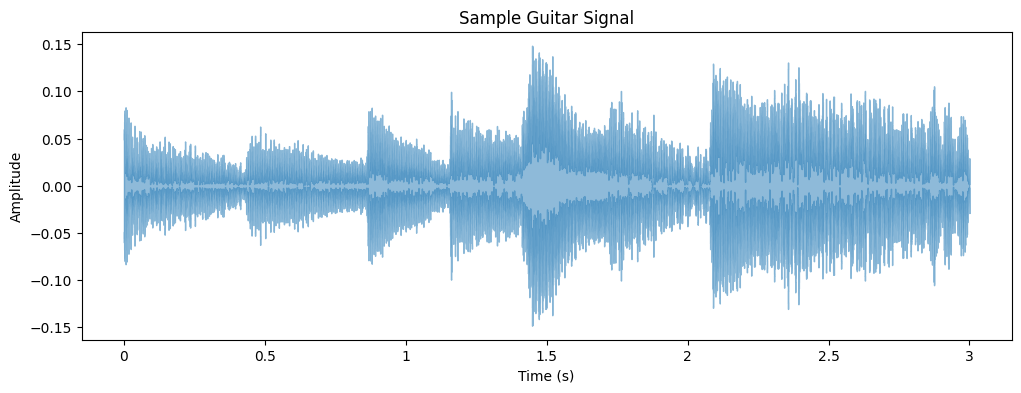

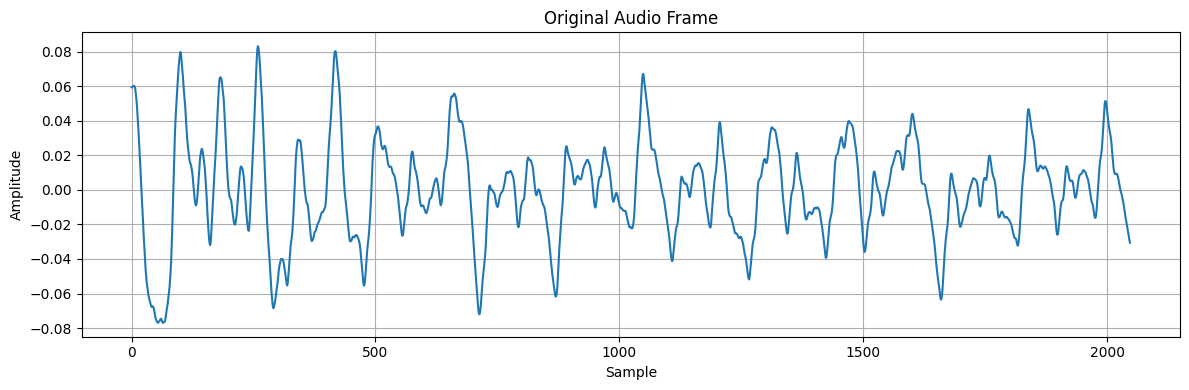

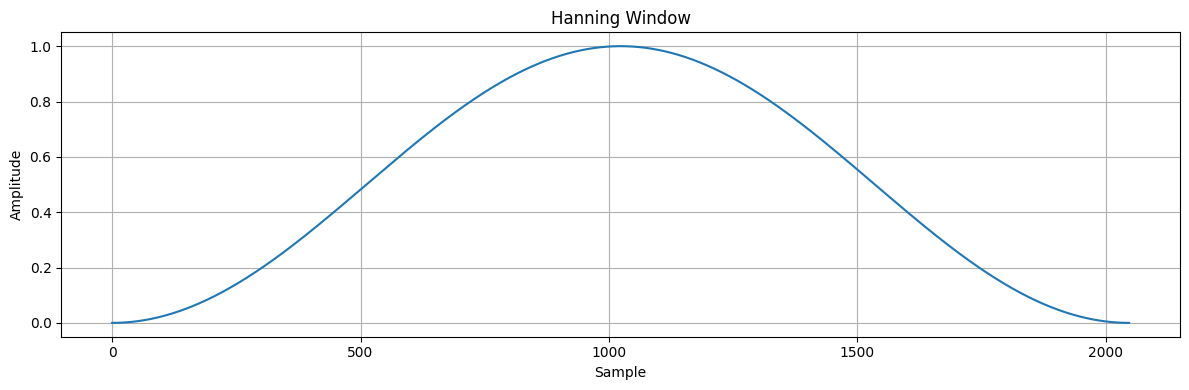

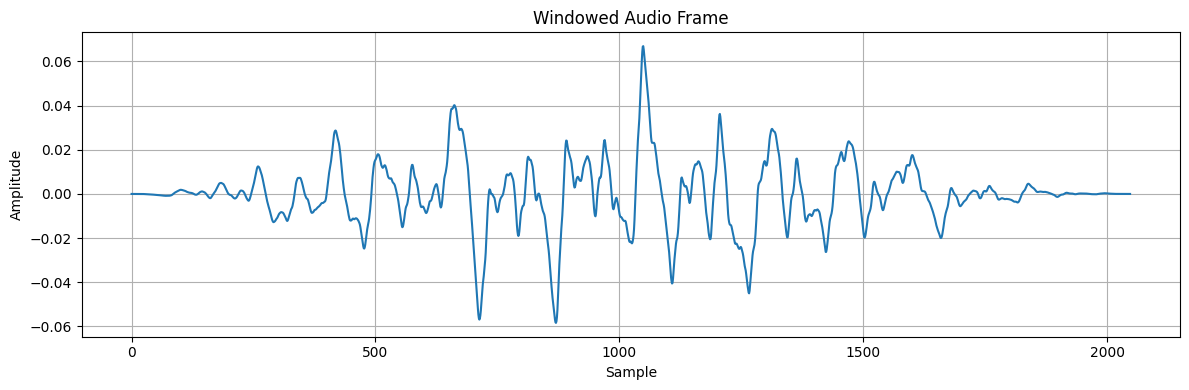

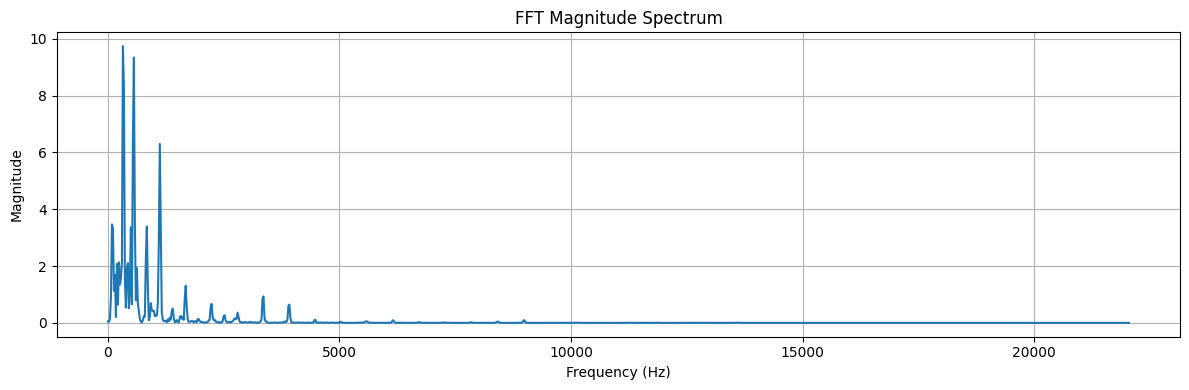

In [11]:
# 0. SAMPLE SIGNAL
ax.set_title("Sample Guitar Signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")

sig.savefig(
    "figures/pre/sample_signal.pdf",
    bbox_inches='tight'
)

display(sig)

# 1. ORIGINAL FRAME
plt.figure(figsize=(12, 4))

plt.plot(frame)

plt.title("Original Audio Frame")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/pre/original_frame.pdf",
    bbox_inches='tight'
)

plt.show()

# 2. HANNING WINDOW
plt.figure(figsize=(12, 4))

plt.plot(window)

plt.title("Hanning Window")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/pre/hanning_window.pdf",
    bbox_inches='tight'
)
plt.show()

# 3. WINDOWED SIGNAL
plt.figure(figsize=(12, 4))

plt.plot(windowed_frame)

plt.title("Windowed Audio Frame")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/pre/windowed_signal.pdf",
    bbox_inches='tight'
)

plt.show()

# 4. FFT MAGNITUDE SPECTRUM
plt.figure(figsize=(12, 4))

plt.plot(
    freqs,
    fft_magnitude
)

plt.title("FFT Magnitude Spectrum")

plt.xlabel("Frequency (Hz)")

plt.ylabel("Magnitude")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/pre/fft_magnitude.pdf",
    bbox_inches='tight'
)

plt.show()

# 2. Summary Statistics and MFCC

In [12]:
audio_path = "dataset/gac/[gac][cla]0518__1.wav" 

y, sr = librosa.load(audio_path, sr=None)
n_fft = 2048
hop_length = 512
n_mels = 26
n_mfcc = 13

# ZERO CROSSING RATE
zcr = librosa.feature.zero_crossing_rate(
    y,
    hop_length=hop_length
)[0]

# RMS
rms = librosa.feature.rms(
    y=y,
    hop_length=hop_length
)[0]

# SPECTRAL CENTROID
centroid = librosa.feature.spectral_centroid(
    y=y,
    sr=sr
)[0]

# SPECTRAL BANDWIDTH
bandwidth = librosa.feature.spectral_bandwidth(
    y=y,
    sr=sr
)[0]

# SPECTRAL ROLLOFF
rolloff = librosa.feature.spectral_rolloff(
    y=y,
    sr=sr,
    roll_percent=0.85
)[0]

# MEL SPECTROGRAM
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

# MFCC
mfcc = librosa.feature.mfcc(
    S=mel_spec_db,
    n_mfcc=n_mfcc
)

# NORMALIZATION FOR PLOTTING
def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

zcr_n = normalize(zcr)
rms_n = normalize(rms)
centroid_n = normalize(centroid)
bandwidth_n = normalize(bandwidth)
rolloff_n = normalize(rolloff)

# TIME AXES
feature_times = librosa.times_like(
    zcr,
    sr=sr,
    hop_length=hop_length
)

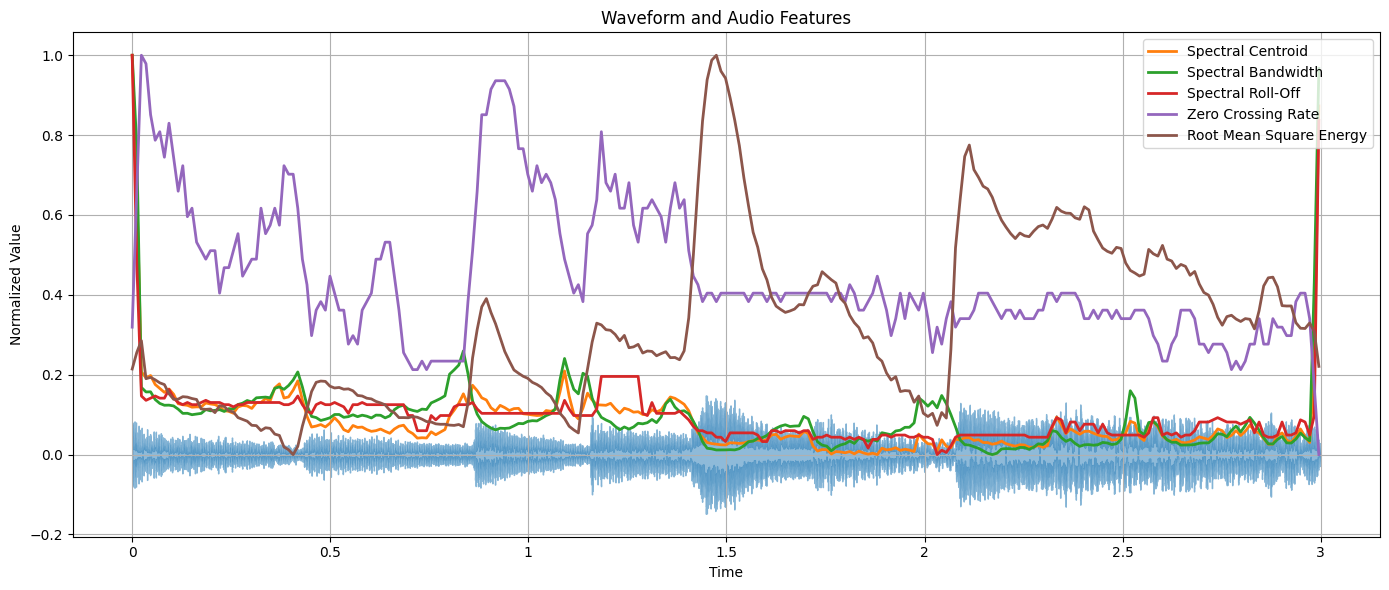

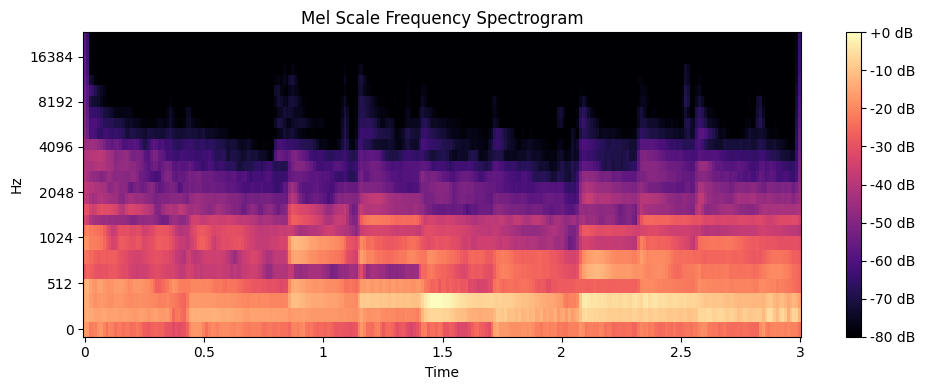

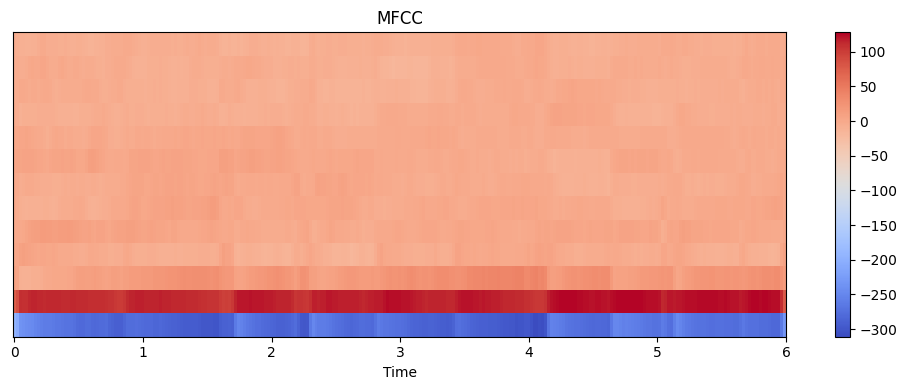

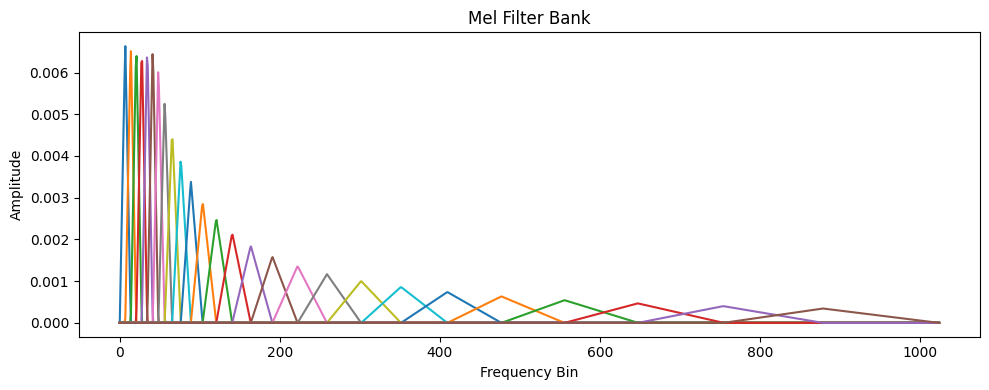

In [13]:
plt.close('all')

# 1. WAVEFORM + FEATURES
plt.figure(figsize=(14, 6))

y, sr = librosa.load(audio_path, sr=None)

librosa.display.waveshow(
    y,
    sr=sr,
    alpha=0.5
)

plt.plot(
    feature_times,
    centroid_n,
    label="Spectral Centroid",
    linewidth=2
)

plt.plot(
    feature_times,
    bandwidth_n,
    label="Spectral Bandwidth",
    linewidth=2
)

plt.plot(
    feature_times,
    rolloff_n,
    label="Spectral Roll-Off",
    linewidth=2
)

plt.plot(
    feature_times,
    zcr_n,
    label="Zero Crossing Rate",
    linewidth=2
)

plt.plot(
    feature_times,
    rms_n,
    label="Root Mean Square Energy",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Normalized Value")

plt.title("Waveform and Audio Features")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/feat/summary_stat.pdf",
    bbox_inches='tight'
)

plt.show()

plt.close()


# 2. MEL SPECTROGRAM
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=hop_length,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')

plt.title("Mel Scale Frequency Spectrogram")

plt.tight_layout()

plt.savefig(
    "figures/feat/spectrogram.pdf",
    bbox_inches='tight'
)

plt.show()

plt.close()


# 3. MFCC
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC")

plt.xlabel("Time")

plt.tight_layout()

plt.savefig(
    "figures/feat/mfcc.pdf",
    bbox_inches='tight'
)

plt.show()

plt.close()


# 4. MEL FILTER BANK
mel_filters = librosa.filters.mel(
    sr=sr,
    n_fft=n_fft,
    n_mels=n_mels
)

plt.figure(figsize=(10, 4))

for i in range(mel_filters.shape[0]):

    plt.plot(mel_filters[i])

plt.title("Mel Filter Bank")

plt.xlabel("Frequency Bin")
plt.ylabel("Amplitude")

plt.tight_layout()

plt.savefig(
    "figures/feat/mel_filterbank.pdf",
    bbox_inches='tight'
)

plt.show()

plt.close()

# 3. Feature Extraction

In [14]:
audio_root = "dataset"

sr = 22050
n_fft = 2048
hop_length = 512

n_mfcc = 13

# LABEL MAP
label_map = {
    "cel": 0,
    "gac": 1,
    "gel": 2,
    "vio": 3
}

# SUMMARY FEATURES
def extract_summary(y, sr):

    zcr = np.mean(
        librosa.feature.zero_crossing_rate(
            y,
            hop_length=hop_length
        )
    )

    rms = np.mean(
        librosa.feature.rms(
            y=y,
            hop_length=hop_length
        )
    )

    centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=y,
            sr=sr
        )
    )

    rolloff = np.mean(
        librosa.feature.spectral_rolloff(
            y=y,
            sr=sr,
            roll_percent=0.85
        )
    )

    bandwidth = np.mean(
        librosa.feature.spectral_bandwidth(
            y=y,
            sr=sr
        )
    )

    return np.array([
        zcr,
        rms,
        centroid,
        rolloff,
        bandwidth
    ])

# MFCC
def extract_mfcc(y, sr):

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )

    return np.mean(mfcc, axis=1)

# STFT
def extract_stft(y, sr):

    stft = librosa.stft(
        y,
        n_fft=n_fft,
        hop_length=hop_length
    )

    mag = np.abs(stft)

    return np.mean(mag, axis=1)

# CQT
def extract_cqt(y, sr):

    cqt = librosa.cqt(
        y,
        sr=sr,
        hop_length=hop_length
    )

    mag = np.abs(cqt)

    return np.mean(mag, axis=1)

In [ ]:
feature_extractors = {
    "mfcc": extract_mfcc,
    "stft": extract_stft,
    "cqt": extract_cqt
}

# EXTRACT + SAVE
for feature_name, extractor in feature_extractors.items():

    print("\n===================================")
    print(f"EXTRACTING {feature_name.upper()} FEATURES")
    print("===================================")

    save_root = f"features/features_{feature_name}"

    os.makedirs(save_root, exist_ok=True)

    labels = []

    total_processed = 0

    # LOOP OVER CLASSES
    for folder in os.listdir(audio_root):

        folder_path = os.path.join(
            audio_root,
            folder
        )

        if not os.path.isdir(folder_path):
            continue

        # LOOP OVER FILES
        for file in os.listdir(folder_path):

            if not file.endswith(".wav"):
                continue

            filepath = os.path.join(
                folder_path,
                file
            )

            try:
                # LOAD AUDIO
                y, sr_local = librosa.load(
                    filepath,
                    sr=sr
                )

                # SUMMARY FEATURES
                summary_feat = extract_summary(
                    y,
                    sr_local
                )

                # MAIN TRANSFORM
                transform_feat = extractor(
                    y,
                    sr_local
                )

                # COMBINE
                final_feat = np.concatenate([
                    summary_feat,
                    transform_feat
                ])

                # FILE KEY
                sample_key = (
                    folder + "_" +
                    file.replace(".wav", "")
                )

                # SAVE FEATURE
                np.save(
                    os.path.join(
                        save_root,
                        sample_key + ".npy"
                    ),
                    final_feat
                )

                # STORE LABEL
                labels.append({
                    "file_key": sample_key,
                    "label": folder,
                    "label_encoded": label_map[folder]
                })

                total_processed += 1

            except Exception as e:

                print("\nERROR:", filepath)
                print(e)

    labels_df = pd.DataFrame(labels)

    labels_df.to_csv(
        os.path.join(save_root, "labels.csv"),
        index=False
    )

    print(f"\nDONE: {feature_name.upper()}")
    print(f"Saved to: {save_root}")
    print(f"Total files processed: {total_processed}")

print("\nALL FEATURE EXTRACTION COMPLETE")


PCA VISUALIZATION: MFCC
Feature shape: (2365, 18)


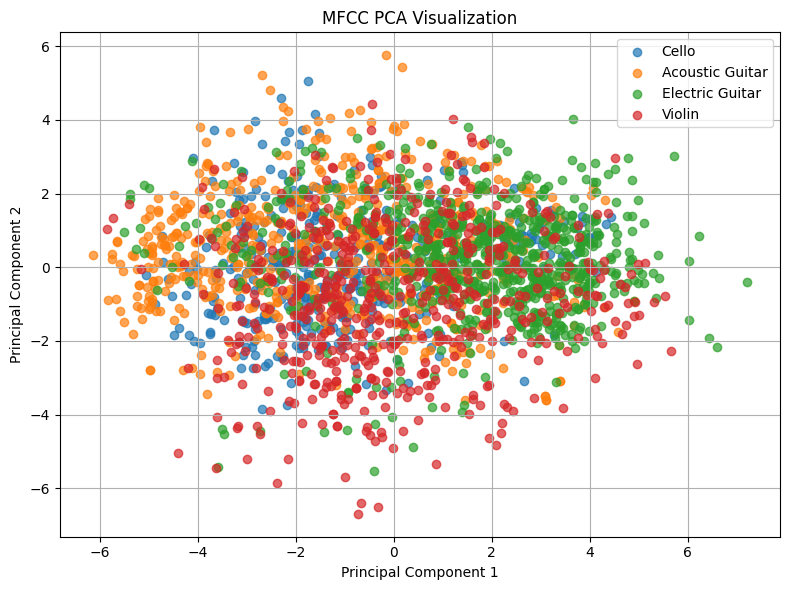


PCA VISUALIZATION: STFT
Feature shape: (2365, 1030)


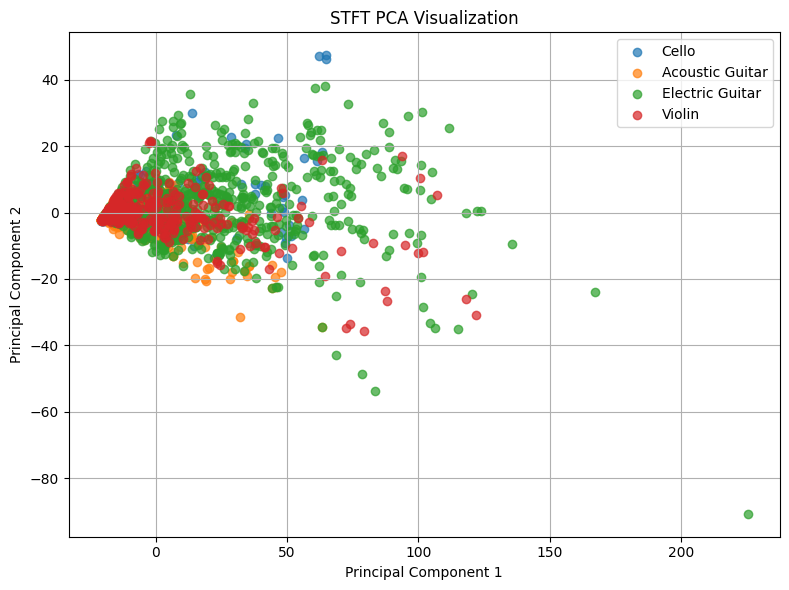


PCA VISUALIZATION: CQT
Feature shape: (2365, 89)


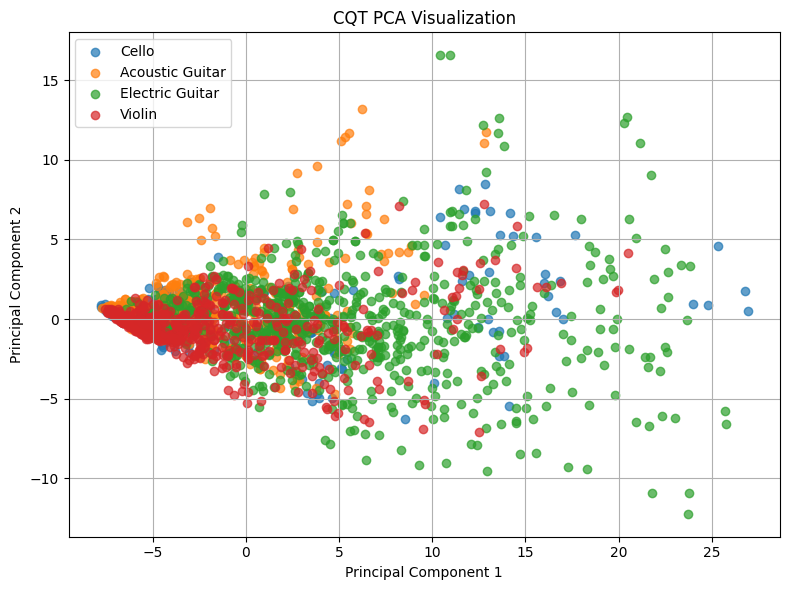


All PCA plots generated and displayed.


In [15]:
feature_dirs = {
    "MFCC": "features/features_mfcc",
    "STFT": "features/features_stft",
    "CQT": "features/features_cqt"
}

class_names = {
    0: "Cello",
    1: "Acoustic Guitar",
    2: "Electric Guitar",
    3: "Violin"
}

os.makedirs("figures/pca_plots", exist_ok=True)

for feature_name, feature_dir in feature_dirs.items():

    print(f"\n===================================")
    print(f"PCA VISUALIZATION: {feature_name}")
    print("===================================")

    labels_path = os.path.join(
        feature_dir,
        "labels.csv"
    )

    df = pd.read_csv(labels_path)

    X = []
    y = []

    for _, row in df.iterrows():

        feature_path = os.path.join(
            feature_dir,
            row["file_key"] + ".npy"
        )

        feat = np.load(feature_path)

        feat = np.asarray(
            feat,
            dtype=np.float32
        )

        X.append(feat)
        y.append(row["label_encoded"])

    X = np.array(X)
    y = np.array(y)

    print("Feature shape:", X.shape)

    # STANDARDIZE
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)

    X_pca = pca.fit_transform(X_scaled)

    # PLOT
    plt.figure(figsize=(8, 6))

    for cls in np.unique(y):

        idx = y == cls

        plt.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=class_names[cls],
            alpha=0.7
        )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    plt.title(f"{feature_name} PCA Visualization")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    # SAVE
    save_path = os.path.join(
        "figures/pca_plots",
        f"{feature_name.lower()}_pca.pdf"
    )

    plt.savefig(save_path)

    # SHOW
    plt.show()

    plt.close()

print("\nAll PCA plots generated and displayed.")

# 4. Training + Evaluation

In [12]:
feature_dirs = {
    "MFCC": "features/features_mfcc",
    "STFT": "features/features_stft",
    "CQT": "features/features_cqt"
}

class_names = [
    "Cello",
    "Acoustic Guitar",
    "Electric Guitar",
    "Violin"
]

os.makedirs("saved_models", exist_ok=True)
os.makedirs("saved_data", exist_ok=True)

for feature_name, feature_dir in feature_dirs.items():

    print("\n===================================")
    print(f"TRAINING {feature_name}")
    print("===================================")

    # LOAD LABELS
    labels_path = os.path.join(
        feature_dir,
        "labels.csv"
    )

    df = pd.read_csv(labels_path)

    X = []
    y = []

    # LOAD FEATURES
    for _, row in df.iterrows():

        feature_path = os.path.join(
            feature_dir,
            row["file_key"] + ".npy"
        )

        feat = np.load(feature_path)

        feat = np.asarray(
            feat,
            dtype=np.float32
        )

        X.append(feat)
        y.append(row["label_encoded"])

    X = np.array(X)
    y = np.array(y)

    print("Shape:", X.shape)

    # TRAIN TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # MODEL
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel='rbf',
            C=10,
            gamma='scale'
        ))
    ])

    # TRAIN
    model.fit(X_train, y_train)

    # SAVE MODEL
    model_path = os.path.join(
        "saved_models",
        f"{feature_name.lower()}_svm.pkl"
    )

    joblib.dump(model, model_path)

    # SAVE TRAIN/TEST DATA
    np.save(
        f"saved_data/{feature_name.lower()}_X_train.npy",
        X_train
    )

    np.save(
        f"saved_data/{feature_name.lower()}_X_test.npy",
        X_test
    )

    np.save(
        f"saved_data/{feature_name.lower()}_y_train.npy",
        y_train
    )

    np.save(
        f"saved_data/{feature_name.lower()}_y_test.npy",
        y_test
    )

    print(f"{feature_name} model saved.")


TRAINING MFCC
Shape: (2365, 18)
MFCC model saved.

TRAINING STFT
Shape: (2365, 1030)
STFT model saved.

TRAINING CQT
Shape: (2365, 89)
CQT model saved.



EVALUATING MFCC


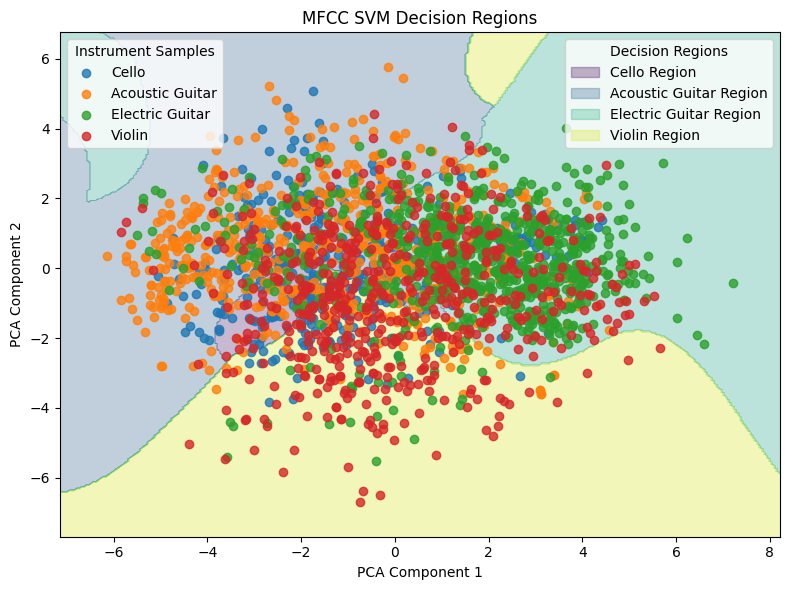


TRAIN PERFORMANCE
Accuracy : 0.9360
Precision: 0.9367
Recall   : 0.9360
F1 Score : 0.9359

TEST PERFORMANCE
Accuracy : 0.7865
Precision: 0.7853
Recall   : 0.7865
F1 Score : 0.7836

EVALUATING STFT


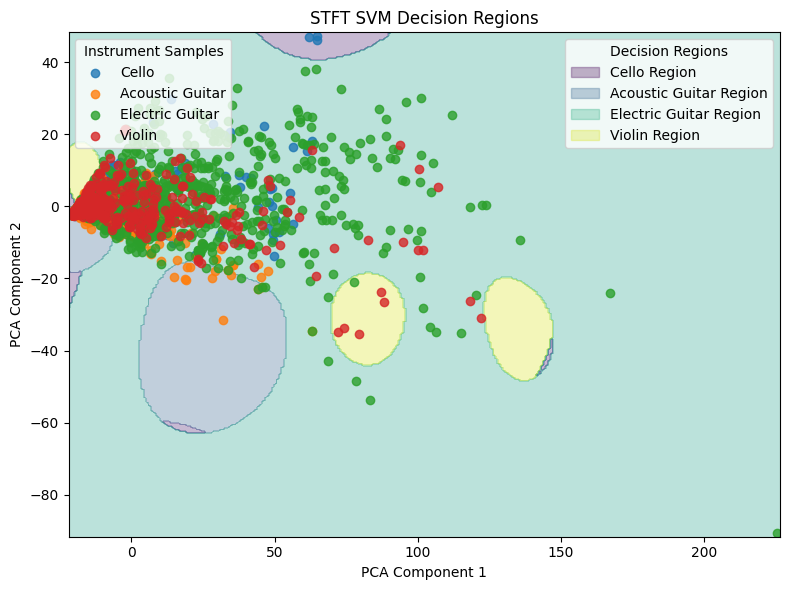


TRAIN PERFORMANCE
Accuracy : 0.8864
Precision: 0.8893
Recall   : 0.8864
F1 Score : 0.8871

TEST PERFORMANCE
Accuracy : 0.7738
Precision: 0.7692
Recall   : 0.7738
F1 Score : 0.7681

EVALUATING CQT


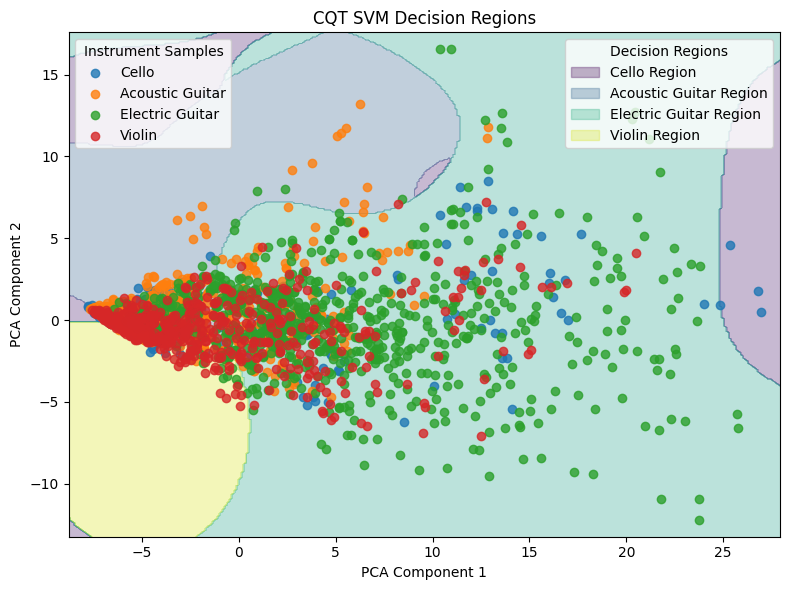


TRAIN PERFORMANCE
Accuracy : 0.8916
Precision: 0.8929
Recall   : 0.8916
F1 Score : 0.8921

TEST PERFORMANCE
Accuracy : 0.7548
Precision: 0.7510
Recall   : 0.7548
F1 Score : 0.7486

FINAL RESULTS
  Feature  Train Accuracy  Train Precision  Train Recall  Train F1  \
0    MFCC        0.936047         0.936705      0.936047  0.935863   
1    STFT        0.886364         0.889342      0.886364  0.887088   
2     CQT        0.891649         0.892939      0.891649  0.892108   

   Test Accuracy  Test Precision  Test Recall   Test F1  
0       0.786469        0.785305     0.786469  0.783615  
1       0.773784        0.769228     0.773784  0.768069  
2       0.754757        0.750956     0.754757  0.748606  


In [16]:
results = []

feature_dirs = {
    "MFCC": "features/features_mfcc",
    "STFT": "features/features_stft",
    "CQT": "features/features_cqt"
}

for feature_name, feature_dir in feature_dirs.items():

    print("\n===================================")
    print(f"EVALUATING {feature_name}")
    print("===================================")

    # LOAD MODEL
    model = joblib.load(
        f"saved_models/{feature_name.lower()}_svm.pkl"
    )

    # LOAD DATA
    X_train = np.load(
        f"saved_data/{feature_name.lower()}_X_train.npy"
    )

    X_test = np.load(
        f"saved_data/{feature_name.lower()}_X_test.npy"
    )

    y_train = np.load(
        f"saved_data/{feature_name.lower()}_y_train.npy"
    )

    y_test = np.load(
        f"saved_data/{feature_name.lower()}_y_test.npy"
    )

    # PREDICTIONS
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # PCA REDUCTION
    scaler = StandardScaler()
    
    X_scaled = scaler.fit_transform(
        np.vstack([X_train, X_test])
    )
    
    pca = PCA(n_components=2)
    
    X_pca = pca.fit_transform(X_scaled)
    
    # TRAIN 2D SVM
    svm_2d = SVC(
        kernel='rbf',
        C=10,
        gamma='scale'
    )
    
    y_all = np.concatenate([y_train, y_test])
    
    svm_2d.fit(X_pca, y_all)
    
    # MESHGRID
    x_min, x_max = (
        X_pca[:, 0].min() - 1,
        X_pca[:, 0].max() + 1
    )
    
    y_min, y_max = (
        X_pca[:, 1].min() - 1,
        X_pca[:, 1].max() + 1
    )
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    Z = svm_2d.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )
    
    Z = Z.reshape(xx.shape)
    
    # PLOT
    plt.figure(figsize=(8, 6))
    
    contour = plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )
    
    for cls in np.unique(y_all):
    
        idx = y_all == cls
    
        plt.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=class_names[cls],
            alpha=0.8
        )
    
    # ---------------------------------------------------------
    # REGION LEGEND
    # ---------------------------------------------------------
    from matplotlib.patches import Patch
    
    region_colors = contour.cmap(
        contour.norm(np.unique(Z))
    )
    
    region_patches = [
        Patch(
            color=region_colors[i],
            alpha=0.3,
            label=f"{class_names[i]} Region"
        )
        for i in range(len(class_names))
    ]
    
    # sample legend
    point_legend = plt.legend(
        loc='upper left',
        title='Instrument Samples'
    )
    
    plt.gca().add_artist(point_legend)
    
    # region legend
    plt.legend(
        handles=region_patches,
        loc='upper right',
        title='Decision Regions'
    )
    
    # ---------------------------------------------------------
    # LABELS
    # ---------------------------------------------------------
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    
    plt.title(
        f"{feature_name} SVM Decision Regions"
    )
    
    plt.tight_layout()
    
    plt.savefig(
        f"figures/svm/{feature_name.lower()}_svm.pdf",
        bbox_inches='tight'
    )
    
    plt.show()
    
    plt.close()
    
    # TRAIN METRICS
    train_acc = accuracy_score(
        y_train,
        y_train_pred
    )

    train_precision = precision_score(
        y_train,
        y_train_pred,
        average='weighted'
    )

    train_recall = recall_score(
        y_train,
        y_train_pred,
        average='weighted'
    )

    train_f1 = f1_score(
        y_train,
        y_train_pred,
        average='weighted'
    )

    # TEST METRICS
    test_acc = accuracy_score(
        y_test,
        y_test_pred
    )

    test_precision = precision_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    test_recall = recall_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    print("\nTRAIN PERFORMANCE")
    print(f"Accuracy : {train_acc:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1 Score : {train_f1:.4f}")

    print("\nTEST PERFORMANCE")
    print(f"Accuracy : {test_acc:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall   : {test_recall:.4f}")
    print(f"F1 Score : {test_f1:.4f}")

    results.append({
        "Feature": feature_name,

        "Train Accuracy": train_acc,
        "Train Precision": train_precision,
        "Train Recall": train_recall,
        "Train F1": train_f1,

        "Test Accuracy": test_acc,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1
    })

results_df = pd.DataFrame(results)

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(results_df)

results_df.to_csv(
    "all_results.csv",
    index=False
)

In [4]:
# =========================================================
# PER-INSTRUMENT METRICS FOR MFCC
# =========================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

# =========================================================
# CONFIG
# =========================================================
feature_name = "mfcc"

class_names = [
    "Cello",
    "Acoustic Guitar",
    "Electric Guitar",
    "Violin"
]

# =========================================================
# LOAD MODEL
# =========================================================
model = joblib.load(
    f"saved_models/{feature_name}_svm.pkl"
)

# =========================================================
# LOAD TEST DATA
# =========================================================
X_test = np.load(
    f"saved_data/{feature_name}_X_test.npy"
)

y_test = np.load(
    f"saved_data/{feature_name}_y_test.npy"
)

# =========================================================
# PREDICT
# =========================================================
y_pred = model.predict(X_test)

# =========================================================
# OVERALL ACCURACY
# =========================================================
overall_accuracy = accuracy_score(
    y_test,
    y_pred
)

# =========================================================
# PER-CLASS METRICS
# =========================================================
precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=np.arange(len(class_names))
    )
)

# =========================================================
# PER-CLASS ACCURACY
# =========================================================
per_class_accuracy = []

for cls in range(len(class_names)):

    idx = y_test == cls

    acc = accuracy_score(
        y_test[idx],
        y_pred[idx]
    )

    per_class_accuracy.append(acc)

# =========================================================
# RESULTS TABLE
# =========================================================
results_df = pd.DataFrame({

    "Instrument": class_names,

    "Accuracy": np.round(
        per_class_accuracy,
        4
    ),

    "Precision": np.round(
        precision,
        4
    ),

    "Recall": np.round(
        recall,
        4
    ),

    "F1-Score": np.round(
        f1,
        4
    )
})

print("\n===================================")
print("MFCC PER-INSTRUMENT PERFORMANCE")
print("===================================")

print(results_df)

print("\nOverall Accuracy:",
      round(overall_accuracy, 4))

results_df.to_csv(
    "mfcc_per_instrument_metrics.csv",
    index=False
)


MFCC PER-INSTRUMENT PERFORMANCE
        Instrument  Accuracy  Precision  Recall  F1-Score
0            Cello    0.6410     0.7812  0.6410    0.7042
1  Acoustic Guitar    0.8189     0.7761  0.8189    0.7969
2  Electric Guitar    0.8947     0.8095  0.8947    0.8500
3           Violin    0.7069     0.7664  0.7069    0.7354

Overall Accuracy: 0.7865


In [6]:
# =========================================================
# COUNT SAMPLES PER INSTRUMENT
# =========================================================

unique, counts = np.unique(
    y,
    return_counts=True
)

print("\n===================================")
print("INSTRUMENT SAMPLE COUNTS")
print("===================================")

for cls, count in zip(unique, counts):

    print(
        f"{class_names[cls]}: {count}"
    )


INSTRUMENT SAMPLE COUNTS
Cello: 388
Acoustic Guitar: 637
Electric Guitar: 760
Violin: 580


CONFUSION MATRIX: MFCC


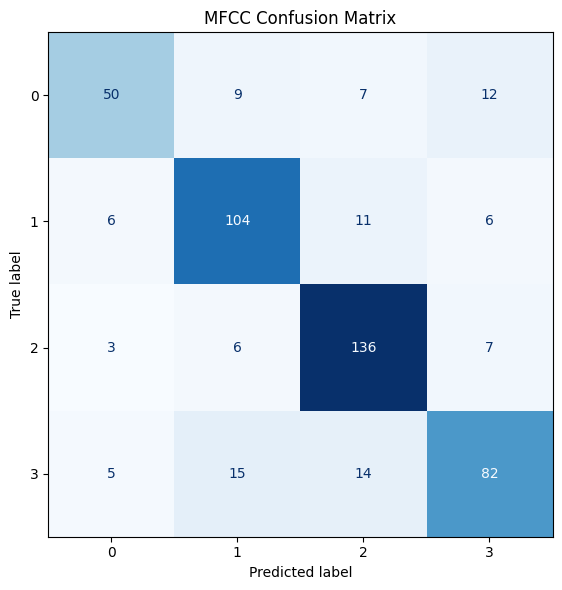

CONFUSION MATRIX: STFT


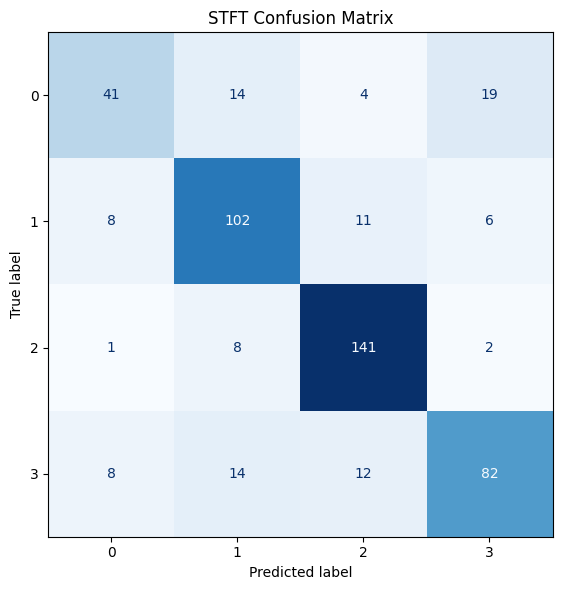

CONFUSION MATRIX: CQT


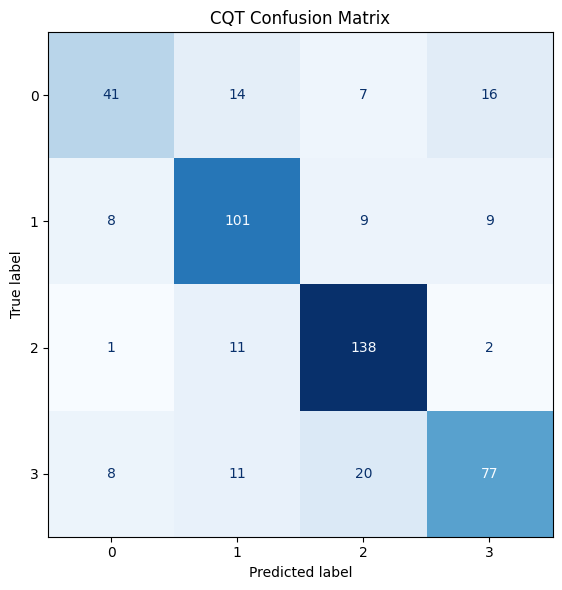

In [17]:
for feature_name, feature_dir in feature_dirs.items():

    print(f"CONFUSION MATRIX: {feature_name}")

    # LOAD MODEL
    model = joblib.load(
        f"saved_models/{feature_name.lower()}_svm.pkl"
    )

    # LOAD TEST DATA
    X_test = np.load(
        f"saved_data/{feature_name.lower()}_X_test.npy"
    )

    y_test = np.load(
        f"saved_data/{feature_name.lower()}_y_test.npy"
    )

    # PREDICT
    y_test_pred = model.predict(X_test)

    # CONFUSION MATRIX
    cm = confusion_matrix(
        y_test,
        y_test_pred
    )

    fig, ax = plt.subplots(figsize=(6, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False
    )

    plt.title(
        f"{feature_name} Confusion Matrix"
    )

    plt.tight_layout()

    plt.savefig(
        f"figures/confusion/{feature_name.lower()}_confusion_matrix.pdf",
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

# 5. Toy Problem for Overview

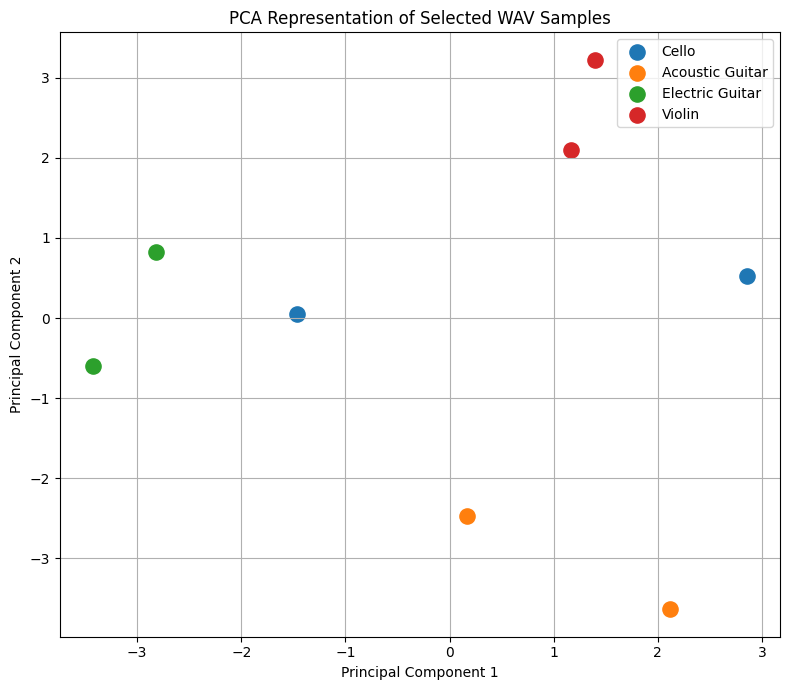

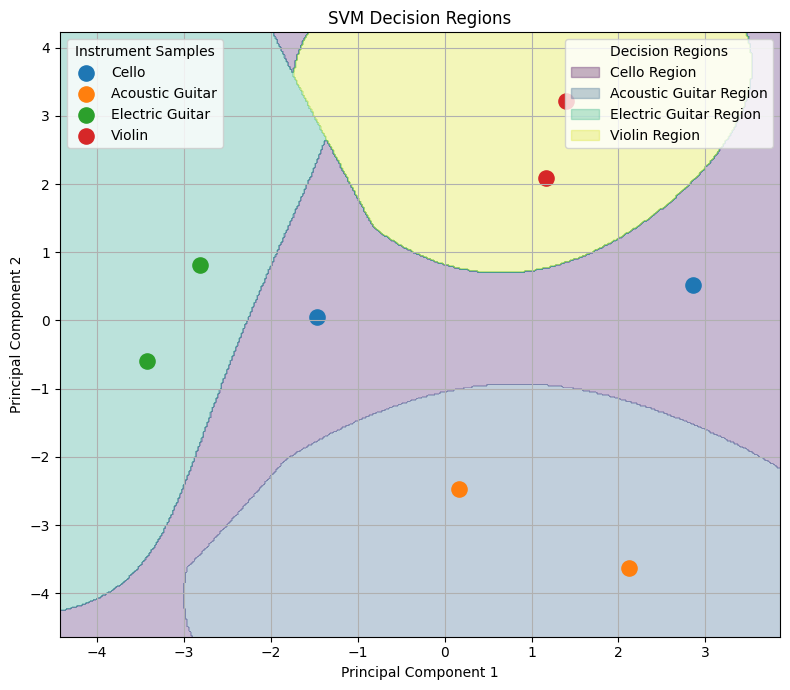

In [18]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

sample_paths = [

    # cello
    "dataset/cel/[cel][cla]0001__1.wav",
    "dataset/cel/[cel][cla]0001__2.wav",

    # acoustic guitar
    "dataset/gac/[gac][cla]0518__1.wav",
    "dataset/gac/[gac][cla]0518__2.wav",

    # electric guitar
    "dataset/gel/[gel][cla]0901__1.wav",
    "dataset/gel/[gel][cla]0901__2.wav",

    # violin
    "dataset/vio/[vio][cla]2083__1.wav",
    "dataset/vio/[vio][cla]2083__2.wav"
]

# LABELS
y = np.array([
    0, 0,
    1, 1,
    2, 2,
    3, 3
])

class_names = [
    "Cello",
    "Acoustic Guitar",
    "Electric Guitar",
    "Violin"
]

# EXTRACT MFCC FEATURES
X = []

for path in sample_paths:

    y_audio, sr = librosa.load(
        path,
        sr=None
    )

    mfcc = librosa.feature.mfcc(
        y=y_audio,
        sr=sr,
        n_mfcc=13
    )

    mfcc_mean = np.mean(
        mfcc,
        axis=1
    )

    X.append(mfcc_mean)

X = np.array(X)

# STANDARDIZE
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA TO 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# TRAIN SVM
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm.fit(X_pca, y)

# SAMPLE NAMES
sample_names = [
    path.split("/")[-1]
    for path in sample_paths
]

# 1. PCA FEATURE DISTRIBUTION
plt.figure(figsize=(8, 7))

for cls in np.unique(y):

    idx = y == cls

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=120,
        label=class_names[cls]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Representation of Selected WAV Samples")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"figures/overview_pca.pdf",
    bbox_inches='tight'
)

plt.show()
plt.close()

from matplotlib.patches import Patch

# =========================================================
# SVM DECISION REGIONS
# =========================================================
x_min, x_max = (
    X_pca[:, 0].min() - 1,
    X_pca[:, 0].max() + 1
)

y_min, y_max = (
    X_pca[:, 1].min() - 1,
    X_pca[:, 1].max() + 1
)

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z = svm.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 7))

# decision regions
contour = plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

# sample points
for cls in np.unique(y):

    idx = y == cls

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=120,
        label=class_names[cls]
    )

# ---------------------------------------------------------
# LEGENDS
# ---------------------------------------------------------
point_legend = plt.legend(
    loc='upper left',
    title='Instrument Samples'
)

plt.gca().add_artist(point_legend)

region_colors = contour.cmap(
    contour.norm(np.unique(Z))
)

region_patches = [
    Patch(
        color=region_colors[i],
        alpha=0.3,
        label=f"{class_names[i]} Region"
    )
    for i in range(len(class_names))
]

plt.legend(
    handles=region_patches,
    loc='upper right',
    title='Decision Regions'
)

# ---------------------------------------------------------
# LABELS
# ---------------------------------------------------------
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("SVM Decision Regions")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"figures/overview_svm.pdf",
    bbox_inches='tight'
)

plt.show()
plt.close()